# Getting Started w/ MMLU Benchmark

# Setup

In [1]:
import os
from pathlib import Path
from random import sample
import sys

from matplotlib import pyplot as plt
from pandas import DataFrame
import torch
from torch import nn
from torch.nn import functional as F

from article.llama import load_config, load_parameters, load_tokenizer, LlamaModel, LlamaHead
from article.mmlu import download_dataset, generate_prompt, load_dataset, Questions, OPTIONS
from article.tools import torch_device

In [2]:
# Configure
project_path = Path(os.environ["PROJECT_ROOT"])
dataset_path = project_path / ".build" / "datasets" / "mmlu"

In [3]:
def show_questions(questions: Questions):
    display(DataFrame(questions))

# MMLU Dataset

The Massive Multitask Language Understanding (MMLU) benchmark dataset from https://github.com/hendrycks/test contains 14,042 MCQs from 57 categories. Each question has 4 options A, B, C, and D and one correct answer. In addition, each category has 5 example questions designed for few-shot experiments.

We first download the dataset and then load the examples and questions.

In [4]:
download_dataset(dataset_path)

Dataset mmlu exists. Skipping.


In [5]:
examples, questions = load_dataset(dataset_path)
categories = {q.category for q in questions}
print(f"Loaded {len(examples)} examples, {len(questions)} questions, {len(categories)} categories")

Loaded 285 examples, 14042 questions, 57 categories


In [6]:
show_questions(sample(questions, k=3))

,qid,category,question,A,B,C,D,answer
0,1265,college medicine,A thin layer chromatography is performed on bo...,SN2 reaction converting an alkyl bromide to an...,Addition reaction converting an alkene to an a...,Nucleophilic acyl substitution reaction conver...,Elimination reaction converting an alcohol to ...,D
1,8408,moral disputes,"According to Marquis, abortion is",absolutely wrong.,seriously presumptively wrong.,generally permissible.,always permissible.,B
2,10939,professional law,A scientist used his car to transport a large ...,"Yes, because the scientist was engaged in an a...","Yes, because the transportation of flammable p...","No, because the doctor assumed the risk by vol...","No, because it was unforeseeable that the doct...",D


# Prompting

We combine each question with the relevant examples to generate few-shot prompts. The prompt template is based on the one used by Hendrycks et al. (2021) and implemented at https://github.com/hendrycks/test.

In [9]:
print(generate_prompt(sample(questions, k=1)[0], n_shots=1, examples=examples))

The following are multiple choice questions (with answers) about high school geography.

Question: The rate of natural increase of a population is found by subtracting the

A) crude death rate from the crude birth date.
B) crude birth rate from the crude death rate.
C) doubling time from the crude birth rate.
D) fertility rate from the crude death rate.

Answer: A

Question: The process whereby immigrants learn the values, language, and customs of their new country is called

A) assimilation.
B) acculturation.
C) adaptation.
D) amalgamation.

Answer: 


# Generating Answers

To evaluate a model's answer to a question in MMLU, we project the semantic embeddings to token space and then compare the raw logits for tokens A, B, C, D.

In [10]:
checkpoint = "Llama3.2-3B"

config = load_config(checkpoint)
device = torch_device()

In [11]:
# Create tokenizer
tokenizer = load_tokenizer(config)

# Create model
model = LlamaModel(config, device)

# Create head
head = LlamaHead(config, device)

In [22]:
# Calculate token ids for options
mmlu_token_ids = {option: tokenizer.encode(option, bos=False, eos=False)[0] for option in OPTIONS}
mmlu_token_ids

{'A': 32, 'B': 33, 'C': 34, 'D': 35}

In [12]:
# Load params for generator
params = load_parameters(config)

# Extract model params
keys = [k for k in params if k.startswith("model.")]
model_params = {k[len("model."):]: params[k] for k in keys}

# Load parameters into model
model.load_state_dict(model_params)
model.eval()

# Extract head params
keys = [k for k in params if k.startswith("head.")]
head_params = {k[len("head."):]: params[k] for k in keys}
head.load_state_dict(head_params)
head.eval()

LlamaHead(
  (normalize): RMSNorm()
  (w_output): Linear(in_features=3072, out_features=128256, bias=False)
)

## Sample question

In [13]:
# Select sample question
q = sample(questions, k=1)
show_questions(q)

,qid,category,question,A,B,C,D,answer
0,12480,professional psychology,An agonist is ___________.,A drug that cannot produce 100% of the biologi...,A drug that has no effect,Another name for antianxiety medication,A drug that binds to a receptor producing a ch...,D


In [14]:
# Generate prompt
prompt = generate_prompt(q[0], n_shots=0, examples=examples)
print(prompt)

The following are multiple choice questions (with answers) about professional psychology.

Question: An agonist is ___________.

A) A drug that cannot produce 100% of the biological response
B) A drug that has no effect
C) Another name for antianxiety medication
D) A drug that binds to a receptor producing a change in activity

Answer: 


In [15]:
# Split prompt into tokens
token_ids = tokenizer.encode(prompt, bos=True, eos=False)

In [18]:
# Load token ids as a tensor
x = torch.tensor(token_ids, device=device)

# Transform token ids into semantic embeddings
x = model(x)

# Project semantic embeddings to token space
x = head(x)

In [19]:
x.shape

torch.Size([128256])

In [23]:
# Select logits for MMLU options
logits = torch.tensor([x[mmlu_token_ids[option]] for option in OPTIONS], device=x.device)
logits

tensor([7.8401, 5.7367, 4.9932, 8.9754], device='mps:0')

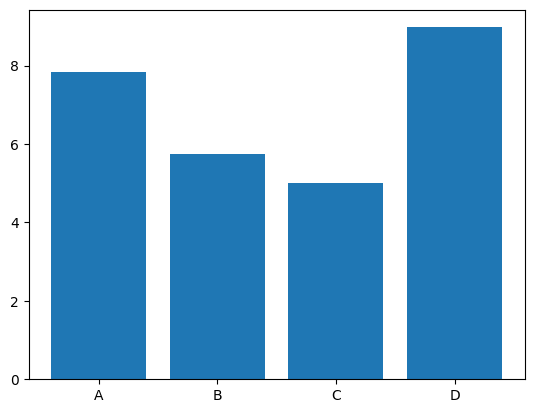

In [35]:
plt.bar([0, 1, 2, 3], logits.cpu())
plt.xticks([0, 1, 2, 3], OPTIONS)
plt.show()

In [37]:
scores = F.softmax(logits, dim=-1)
scores

tensor([0.2330, 0.0284, 0.0135, 0.7251], device='mps:0')

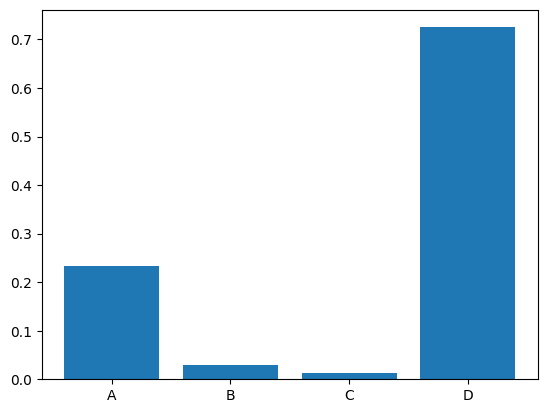

In [38]:
plt.bar([0, 1, 2, 3], scores.cpu())
plt.xticks([0, 1, 2, 3], OPTIONS)
plt.show()

In [39]:
q[0]

Question(qid=12480, category='professional psychology', question='An agonist is ___________.', A='A drug that cannot produce 100% of the biological response', B='A drug that has no effect', C='Another name for antianxiety medication', D='A drug that binds to a receptor producing a change in activity', answer='D')